# Druksensor ijken en maken van een $pV$-diagram

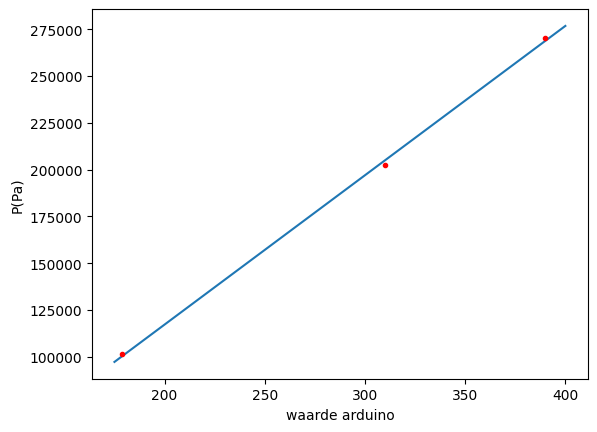

In [30]:
# resultaten deel 1 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
U1 = 179 # 40 ml
U2 = 310 # 20 ml 
U3 = 390 # 15 ml 

P_atm = np.array([1,2,40/15])
P_1 = P_atm*(1.01325*10**5)
U = np.array([U1,U2,U3])

def fit(U,a,b):
    return U*a+b

val,cov = curve_fit(fit,U,P_1)
U_test = np.linspace(175,400,100)

plt.figure()
plt.plot(U_test,fit(U_test,*val))
plt.plot(U,P_1,"r.")
plt.ylabel("P(Pa)")
plt.xlabel("waarde arduino")
plt.show()

In [31]:
#C bepalen van PV = C
V_1 = np.array([40,20,15])

C = np.mean(V_1 * P_1)


In [32]:
# resultaten deel 2 
U1_2 = 179 # 40 ml 
U2_2 = 290 # 20 ml 
U3_2 = 460 # 10 ml 


U_2 = np.array([U1_2, U2_2, U3_2])


V_2 = np.array([40,20,10])

P_2 = fit(U_2,*val)

V_tube = C / P_2 - V_2

print("De inhoud van de tube is %.3f mL" %(np.mean(V_tube)))


De inhoud van de tube is 1.426 mL


In [33]:
# resultaten deel 2 
U1_2 = 179  # 40 ml 
U2_2 = 290  # 20 ml 
U3_2 = 460  # 10 ml 

U_2 = np.array([U1_2, U2_2, U3_2])
V_2 = np.array([40, 20, 10])

P_2 = fit(U_2, *val)

V_tube = C / P_2 - V_2

V_mean = np.mean(V_tube)
V_unc  = np.std(V_tube, ddof=1)   #Ruwe onzekerheid

print("De inhoud van de tube is %.3f ± %.3f mL" % (V_mean, V_unc))


De inhoud van de tube is 1.426 ± 1.069 mL
